In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn import naive_bayes
from sklearn import tree

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
import shap

In [7]:
df = pd.read_csv('/content/data2.csv')
df

,type_school,school_accreditation,gender,interest,residence,parent_age,parent_salary,house_area,average_grades,parent_was_in_college,will_go_to_college
0,Academic,A,Male,Less Interested,Urban,56,6950000,83.0,84.09,False,True
1,Academic,A,Male,Less Interested,Urban,57,4410000,76.8,86.91,False,True
2,Academic,B,Female,Very Interested,Urban,50,6500000,80.6,87.43,False,True
3,Vocational,B,Male,Very Interested,Rural,49,6600000,78.2,82.12,True,True
4,Academic,A,Female,Very Interested,Urban,57,5250000,75.1,86.79,False,False
...,...,...,...,...,...,...,...,...,...,...,...
995,Vocational,A,Female,Very Interested,Rural,49,7420000,63.6,85.99,True,True
996,Academic,B,Female,Less Interested,Rural,51,7480000,84.3,89.72,True,True
997,Vocational,A,Male,Less Interested,Urban,49,5550000,75.2,79.56,False,True
998,Academic,B,Male,Uncertain,Rural,53,5840000,105.8,87.18,True,True


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   type_school            1000 non-null   object 
 1   school_accreditation   1000 non-null   object 
 2   gender                 1000 non-null   object 
 3   interest               1000 non-null   object 
 4   residence              1000 non-null   object 
 5   parent_age             1000 non-null   int64  
 6   parent_salary          1000 non-null   int64  
 7   house_area             1000 non-null   float64
 8   average_grades         1000 non-null   float64
 9   parent_was_in_college  1000 non-null   bool   
 10  will_go_to_college     1000 non-null   bool   
dtypes: bool(2), float64(2), int64(2), object(5)
memory usage: 72.4+ KB


Logistic Regression
_________________________________________________________
Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.79      0.74      0.76       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.77      0.77      0.77       200

Confusion Matrix:
 [[80 20]
 [26 74]]
---------------------------------------------------------

SHAP summary


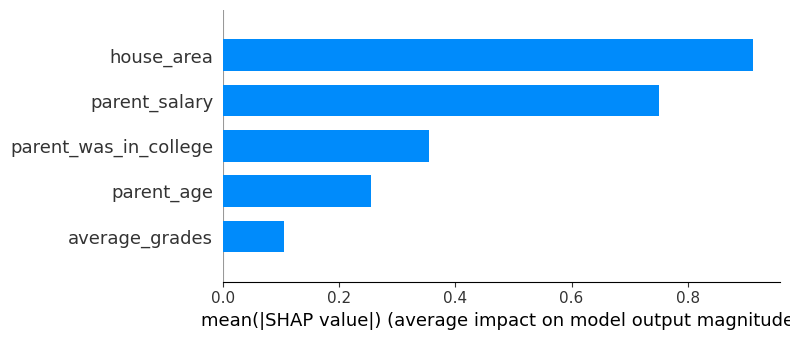

In [12]:
# target varijabla
y = df["will_go_to_college"].astype(int)

# brišem kolone koje nisu numeričke, ali ostavljam kolone s bool vrijednošću
X = df.drop(columns=["will_go_to_college", "type_school", "school_accreditation", "gender", "interest", "residence"])

# konvertiram bool kolonu u int
if "parent_was_in_college" in X.columns: X["parent_was_in_college"] = X["parent_was_in_college"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train, y_train)

#Log reg
y_pred = model.predict(X_test)
print("Logistic Regression")
print("_________________________________________________________")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("---------------------------------------------------------")
print()


#SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
print("SHAP summary")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)